## Regression on Wine Quality (`main_report.ipynb`)


In [1]:
## Import data manipulators and visualisers
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import the relevant Scikit libraries.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

wine_df = pd.read_csv('data.csv')
wine_df = wine_df.dropna()
wine_df = wine_df.drop_duplicates()

X = wine_df.drop(['wine_type','quality'], axis=1)
y = wine_df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.2, random_state=42, stratify=y, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,test_size=0.25, random_state=42, stratify=y_train, shuffle=True)
degrees = range(1, 7)
train_errors = []
val_errors = []

## Need to loop through the degrees

for deg in tqdm(degrees, desc='Eval Degrees', colour='Blue'): 
    ## Generating each Poly degree
    poly = PolynomialFeatures(degree=deg)

    ## transform the dataset so that it could be used to train the model. 
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    ## Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    ## Predictions
    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_val_poly)

    ## Calculate MSE (MSE is Mean Square Error, this is like saynig how wrong is my model on average Low training MSE and Low val MSE Good model 
    ## Low train + High val MSE = Overfitting & High train and High Val MSE = Underfitting 
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    val_errors.append(mean_squared_error(y_val, y_val_pred))


Eval Degrees: 100%|██████████| 6/6 [00:07<00:00,  1.33s/it]


In [2]:
for degree, train_error, val_error in zip(degrees, train_errors, val_errors):
    print(f"Degree {degree}")
    print(f"  Training MSE:  {train_error:.4f}")
    print(f"  Validation MSE: {val_error:.4f}")

Degree 1
  Training MSE:  0.5249
  Validation MSE: 0.5767
Degree 2
  Training MSE:  0.4643
  Validation MSE: 0.5613
Degree 3
  Training MSE:  0.3891
  Validation MSE: 1.1134
Degree 4
  Training MSE:  0.1980
  Validation MSE: 366.9547
Degree 5
  Training MSE:  0.0469
  Validation MSE: 1447.9302
Degree 6
  Training MSE:  0.1612
  Validation MSE: 1124.7445


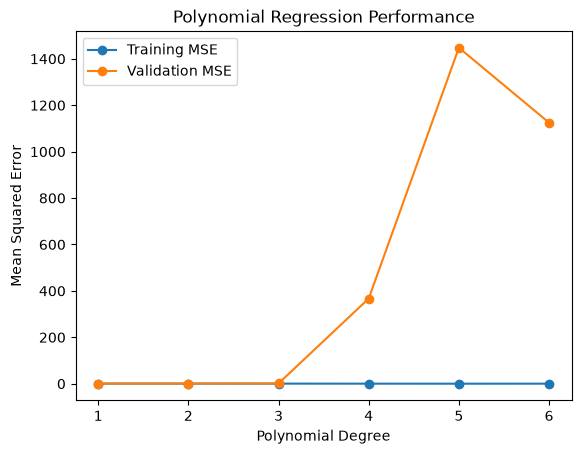

In [3]:
plt.plot(degrees, train_errors, marker="o", label="Training MSE")
plt.plot(degrees, val_errors, marker="o", label="Validation MSE")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Polynomial Regression Performance")
plt.xticks(degrees)
plt.legend()
plt.show()

### Loading the best model

In [4]:
from assignment_1 import load_best_model

best_model_pipeline = load_best_model()

y_pred = best_model_pipeline.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {test_mse:.4f}")


Test MSE: 0.5271


In [5]:
# then you can use this model to make prediction on the test set and generate figure for your report.

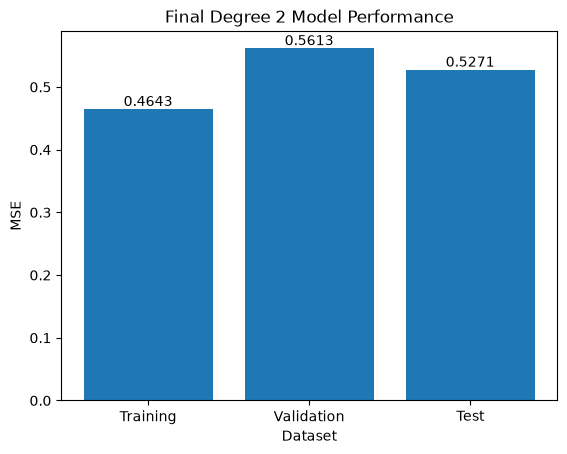

In [8]:
datasets = ["Training", "Validation", "Test"]
mse_values = [0.4643, 0.5613, 0.5271]

bars = plt.bar(datasets, mse_values)

plt.xlabel("Dataset")
plt.ylabel("MSE")
plt.title("Final Degree 2 Model Performance")

## Values above bars
for bar, value in zip(bars, mse_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x position
        bar.get_height(),                  # y position
        f"{value:.4f}",                    # label text
        ha="center",                       # horizontal alignment
        va="bottom"                       # vertical alignment
    )

plt.show()